# Laboratorio #7 — NLP end-to-end y Embeddings

**CC3092 · Deep Learning y Sistemas Inteligentes** — Universidad del Valle de Guatemala

**Nicolás Concuá** · Guatemala, octubre de 2026

Repositorio: https://github.com/nicoCT04/Lab7-DL

Este notebook construye un pipeline de NLP de punta a punta: **texto crudo → tokens → IDs → vectores → modelo → salida**.
Se entrenan embeddings de palabras propios sobre WikiText-103 (**skip-gram con negative sampling** implementado en
PyTorch y, como referencia, **Word2Vec de gensim**), se comparan con **GloVe preentrenado** (100 d), se verifica la
aritmética vectorial (*king − man + woman ≈ queen*) y, al final, se usan los embeddings para clasificar noticias de
**AG News**.

## 0. Configuración del entorno

**Hardware:** Apple M4 Pro (GPU integrada, backend **MPS** de PyTorch). El código usa CUDA automáticamente si existe.

Variable de entorno opcional `LAB7_QUICK=1`: usa un subconjunto pequeño del corpus (prueba de humo).

In [1]:
# Descomenta para instalar dependencias (p. ej. en Colab):
# !pip install torch gensim datasets nltk scikit-learn scipy pandas matplotlib

In [2]:
import os, re, time, math, json, random, platform, subprocess, warnings
from collections import Counter
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
import gensim
import gensim.downloader as api
from gensim.test.utils import datapath
import nltk

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)

# Semilla global para reproducibilidad.
SEED = 42
def fijar_semillas(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
fijar_semillas()

# Rutas robustas: funcionan tanto si se corre desde la raíz del lab como desde notebook/.
_EN_NOTEBOOK = os.path.basename(os.getcwd()) == 'notebook'
RAIZ    = '..' if _EN_NOTEBOOK else '.'
DATA    = os.path.join(RAIZ, 'data')        # cachés pesadas (no se versionan)
REPORTS = os.path.join(RAIZ, 'reports')     # figuras y tablas
os.makedirs(DATA, exist_ok=True); os.makedirs(REPORTS, exist_ok=True)

QUICK = os.environ.get('LAB7_QUICK') == '1'

# Dispositivo: CUDA > MPS (Apple Silicon) > CPU.
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

def nombre_hardware():
    if DEVICE.type == 'cuda':
        return torch.cuda.get_device_name(0)
    try:
        chip = subprocess.check_output(['sysctl', '-n', 'machdep.cpu.brand_string']).decode().strip()
    except Exception:
        chip = platform.processor()
    return f'{chip} ({DEVICE.type.upper()})'

HARDWARE = nombre_hardware()
print('torch', torch.__version__, '| gensim', gensim.__version__)
print('dispositivo:', DEVICE, '|', HARDWARE, '| QUICK =', QUICK)

torch 2.14.1 | gensim 4.4.0
dispositivo: mps | Apple M4 Pro (MPS) | QUICK = False


## 1. Datos

- **WikiText-103 (raw):** artículos de Wikipedia, para entrenar los embeddings propios.
- **AG News:** noticias en 4 categorías (World, Sports, Business, Sci/Tech), para la tarea final (sección 6).
- **GloVe `glove-wiki-gigaword-100`:** embeddings preentrenados de referencia (Wikipedia + Gigaword, 6 mil millones de tokens).
- **Benchmarks (incluidos en gensim):** `questions-words.txt` (analogías), `wordsim353.tsv` y `simlex999.txt` (similitud).

In [3]:
corpus = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1")
news   = load_dataset("fancyzhx/ag_news")
glove  = api.load("glove-wiki-gigaword-100")

ANALOGIAS = datapath("questions-words.txt")
WORDSIM   = datapath("wordsim353.tsv")
SIMLEX    = datapath("simlex999.txt")

print(corpus)
print(news)
print('GloVe:', len(glove.key_to_index), 'palabras ×', glove.vector_size, 'dimensiones')

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 1801350
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
GloVe: 400000 palabras × 100 dimensiones


## 2. Exploración y preprocesamiento del texto

### 2.1 ¿Cómo viene el texto crudo?

WikiText-103 viene **una línea por párrafo**. Los títulos de artículo tienen la forma ` = Título = ` y las secciones
` = = Sección = = `. Además, la versión *raw* trae marcadores propios del dataset: ` @-@ ` (guion dentro de palabra),
` @,@ ` (separador de miles) y ` @.@ ` (punto decimal). No contiene `<unk>` (eso solo existe en la versión no-raw).

In [4]:
lineas = corpus['train']['text']
for l in lineas[1:6]:
    print(repr(l[:160]))

' = Valkyria Chronicles III = \n'
''
' Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III '
' The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the '
' It met with positive sales in Japan , and was praised by both Japanese and western critics . After release , it received downloadable content , along with an e'


In [5]:
# Expresiones regulares para reconocer la estructura del corpus.
RE_TITULO  = re.compile(r'^ = [^=].* = \n$')       # " = Título = "  -> inicio de un artículo
RE_SECCION = re.compile(r'^ (= )+.*(= )+\n$')      # cualquier encabezado (título o sección)

n_lineas      = len(lineas)
n_vacias      = sum(1 for l in lineas if not l.strip())
n_titulos     = sum(1 for l in lineas if RE_TITULO.match(l))
n_encabezados = sum(1 for l in lineas if RE_SECCION.match(l))
n_parrafos    = n_lineas - n_vacias - n_encabezados
n_tokens_raw  = sum(len(l.split()) for l in lineas)  # tokens "oficiales" del dataset (separados por espacio, incluye puntuación)

print(f'Líneas totales        : {n_lineas:,}')
print(f'  vacías              : {n_vacias:,}')
print(f'  encabezados         : {n_encabezados:,}  (de ellos, títulos de artículo: {n_titulos:,})')
print(f'  párrafos de texto   : {n_parrafos:,}')
print(f'Artículos (títulos)   : {n_titulos:,}')
print(f'Tokens crudos (split) : {n_tokens_raw:,}')

Líneas totales        : 1,801,350
  vacías              : 636,321
  encabezados         : 305,074  (de ellos, títulos de artículo: 29,444)
  párrafos de texto   : 859,955
Artículos (títulos)   : 29,444
Tokens crudos (split) : 101,425,671


> El conteo de títulos (≈29.4 k) es un poco mayor que los 28,475 artículos oficiales de WikiText-103 porque algunos
> artículos contienen líneas con el mismo formato ` = X = `; para este lab se usa el título como frontera de artículo.

### 2.2 Normalización (y por qué)

Decisiones, pensadas para ser **consistentes con el vocabulario de GloVe 6B** (que es *uncased* y fue tokenizado con
el tokenizador de Stanford, estilo Penn Treebank):

| Decisión | Qué se hace | Justificación |
|---|---|---|
| Marcadores `@-@`, `@,@`, `@.@` | se reconstruyen (`role @-@ playing` → `role-playing`, `1 @,@ 000` → `1,000`) | son artefactos del dataset, no texto real |
| Minúsculas | todo a minúsculas | GloVe 6B es *uncased*: si no, `King` y `king` no existirían en GloVe y la comparación sería injusta |
| Puntuación | se elimina | no aporta a analogías/similitud y ocupa ~15 % de los tokens (desperdicia ventanas de contexto) |
| Números | se conservan como dígitos (`1990`, `3.5`, `1,000`) | GloVe también los guarda como dígitos; los años son contexto útil |
| Guiones | se separan (`role-playing` → `role`, `playing`) | aumenta la frecuencia de las palabras base; GloVe contiene ambas formas |
| Contracciones | estilo PTB: `don't` → `do n't`, `king's` → `king 's` (WikiText trae `don 't`, se corrige a `do n't`) | es exactamente como las tokenizó GloVe (`n't` y `'s` son palabras en su vocabulario) |
| Caracteres no ASCII | se conservan las letras Unicode (`é`, `ñ`) | GloVe también las contiene |
| Tokens especiales | `<unk>` para palabras fuera del vocabulario y `<pad>` (índice 0) para relleno | solo se usan en la clasificación (sección 6); en skip-gram las palabras raras simplemente se descartan, como hace Word2Vec |

Lo que **debe ser consistente con GloVe** para que la comparación sea justa: minúsculas, el manejo de números y la
separación de contracciones. Si, por ejemplo, conserváramos mayúsculas, muchas palabras de las analogías no
coincidirían con GloVe y la cobertura sería distinta entre modelos.

In [6]:
RE_MARCAS = re.compile(r' @([-,.])@ ')                     # " @-@ " -> "-"
RE_NT     = re.compile(r"(\w)n't\b")                        # "don't" -> "do n't"
RE_NT_WT  = re.compile(r"(\w)n 't\b")                       # WikiText escribe "don 't" -> "do n't"
RE_CLIT   = re.compile(r"(\w)'(s|re|ve|ll|d|m)\b")          # "king's" -> "king 's"
RE_TOKEN  = re.compile(r"n't|'(?:s|re|ve|ll|d|m)\b"         # clíticos
                       r"|[^\W\d_]+"                         # palabras (letras Unicode)
                       r"|\d+(?:[.,]\d+)*")                  # números: 1990, 3.5, 1,000

def normalizar(texto):
    """Texto crudo -> texto normalizado (marcas de WikiText, minúsculas, contracciones separadas)."""
    t = RE_MARCAS.sub(r'\1', texto).lower()
    t = RE_NT_WT.sub(r"\1 n't", t)
    t = RE_NT.sub(r"\1 n't", t)
    t = RE_CLIT.sub(r"\1 '\2", t)
    return t

def tokenizar(texto):
    """Tokenizador propio por palabra: normaliza y extrae palabras, números y clíticos.
    Todo lo que no coincide con RE_TOKEN (puntuación, guiones, símbolos) se descarta."""
    return RE_TOKEN.findall(normalizar(texto))

print(tokenizar(lineas[3])[:40])

['senjō', 'no', 'valkyria', '3', 'unrecorded', 'chronicles', 'japanese', '戦場のヴァルキュリア', '3', 'lit', 'valkyria', 'of', 'the', 'battlefield', '3', 'commonly', 'referred', 'to', 'as', 'valkyria', 'chronicles', 'iii', 'outside', 'japan', 'is', 'a', 'tactical', 'role', 'playing', 'video', 'game', 'developed', 'by', 'sega', 'and', 'media', 'vision', 'for', 'the', 'playstation']


### 2.3 Tokenizador propio vs. NLTK

Se compara con `nltk.word_tokenize` (Treebank mejorado) en 12 oraciones con casos difíciles. Para comparar solo la
**segmentación**, a la salida de NLTK se le aplican las mismas minúsculas.

In [7]:
nltk.download('punkt', quiet=True); nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import word_tokenize

oraciones = [
    "I don't think it's ready yet.",
    "She can't attend the meeting, but they'll call later.",
    "The U.S. economy grew 3.5% in 2019.",
    "Dr. Smith arrived at 5 p.m. on Jan. 3rd.",
    "It's a state-of-the-art, well-known system.",
    "The company's revenue was $1,000,000 last year.",
    "\"Hello!\" he said -- then left...",
    "We'd've gone if you'd asked.",
    "E-mail me at john.doe@example.com or visit www.uvg.edu.gt",
    "The Beatles' songs (1962-1970) remain popular.",
    "New York-based firms hired 1,200 workers.",
    "Pokémon is a café's favorite game, isn't it?",
]

filas = []
for o in oraciones:
    propio = tokenizar(o)
    ref = [t.lower() for t in word_tokenize(o)]
    filas.append({'oración': o, 'propio': ' | '.join(propio), 'nltk': ' | '.join(ref),
                  'iguales': propio == ref})
df_tok = pd.DataFrame(filas)
with pd.option_context('display.max_colwidth', 80):
    display(df_tok[['oración', 'propio', 'nltk']])
df_tok.to_csv(os.path.join(REPORTS, 'tokenizadores.csv'), index=False)

,oración,propio,nltk
0,I don't think it's ready yet.,i | do | n't | think | it | 's | ready | yet,i | do | n't | think | it | 's | ready | yet | .
1,"She can't attend the meeting, but they'll call later.",she | ca | n't | attend | the | meeting | but | they | 'll | call | later,"she | ca | n't | attend | the | meeting | , | but | they | 'll | call | late..."
2,The U.S. economy grew 3.5% in 2019.,the | u | s | economy | grew | 3.5 | in | 2019,the | u.s. | economy | grew | 3.5 | % | in | 2019 | .
3,Dr. Smith arrived at 5 p.m. on Jan. 3rd.,dr | smith | arrived | at | 5 | p | m | on | jan | 3 | rd,dr. | smith | arrived | at | 5 | p.m. | on | jan. | 3rd | .
4,"It's a state-of-the-art, well-known system.",it | 's | a | state | of | the | art | well | known | system,"it | 's | a | state-of-the-art | , | well-known | system | ."
5,"The company's revenue was $1,000,000 last year.","the | company | 's | revenue | was | 1,000,000 | last | year","the | company | 's | revenue | was | $ | 1,000,000 | last | year | ."
6,"""Hello!"" he said -- then left...",hello | he | said | then | left,`` | hello | ! | '' | he | said | -- | then | left | ...
7,We'd've gone if you'd asked.,we | 'd | 've | gone | if | you | 'd | asked,we'd | 've | gone | if | you | 'd | asked | .
8,E-mail me at john.doe@example.com or visit www.uvg.edu.gt,e | mail | me | at | john | doe | example | com | or | visit | www | uvg | e...,e-mail | me | at | john.doe | @ | example.com | or | visit | www.uvg.edu.gt
9,The Beatles' songs (1962-1970) remain popular.,the | beatles | songs | 1962 | 1970 | remain | popular,the | beatles | ' | songs | ( | 1962-1970 | ) | remain | popular | .


In [8]:
# Diferencias token a token (lo que tiene uno y no el otro).
for o in oraciones:
    a, b = Counter(tokenizar(o)), Counter(t.lower() for t in word_tokenize(o))
    solo_p, solo_n = list((a - b).elements()), list((b - a).elements())
    print(f'{o[:45]:45s} | solo propio: {solo_p} | solo NLTK: {solo_n}')

I don't think it's ready yet.                 | solo propio: [] | solo NLTK: ['.']
She can't attend the meeting, but they'll cal | solo propio: [] | solo NLTK: [',', '.']
The U.S. economy grew 3.5% in 2019.           | solo propio: ['u', 's'] | solo NLTK: ['u.s.', '%', '.']
Dr. Smith arrived at 5 p.m. on Jan. 3rd.      | solo propio: ['dr', 'p', 'm', 'jan', '3', 'rd'] | solo NLTK: ['dr.', 'p.m.', 'jan.', '3rd', '.']
It's a state-of-the-art, well-known system.   | solo propio: ['state', 'of', 'the', 'art', 'well', 'known'] | solo NLTK: ['state-of-the-art', ',', 'well-known', '.']
The company's revenue was $1,000,000 last yea | solo propio: [] | solo NLTK: ['$', '.']
"Hello!" he said -- then left...              | solo propio: [] | solo NLTK: ['``', '!', "''", '--', '...']
We'd've gone if you'd asked.                  | solo propio: ['we', "'d"] | solo NLTK: ["we'd", '.']
E-mail me at john.doe@example.com or visit ww | solo propio: ['e', 'mail', 'john', 'doe', 'example', 'com', 'www', 'u

**Dónde difieren:**

- **Contracciones:** ambos las separan igual (`do n't`, `it 's`, `ca n't`, `they 'll`) — se diseñó así a propósito para
  imitar el estilo PTB de GloVe. Diferencia: `we'd've` → NLTK deja `'ve` pegado de otra forma.
- **Guiones:** NLTK conserva `state-of-the-art` y `well-known` como un token; el propio los separa en palabras.
- **Abreviaturas:** NLTK reconoce `U.S.`, `Dr.`, `p.m.`, `Jan.` como un solo token; el propio las rompe (`u`, `s`) o
  quita el punto (`dr`). Esto es lo que más pierde el tokenizador por regex.
- **Puntuación y símbolos:** NLTK emite `,` `.` `$` `%` `"` `(` como tokens; el propio los descarta.
- **Correos/URLs:** NLTK los parte por `@`; el propio los parte en todas las piezas alfanuméricas.

Conclusión: el tokenizador propio es más simple y agresivo (sin puntuación), lo cual es adecuado para entrenar
embeddings de palabras; NLTK es más fiel lingüísticamente (abreviaturas), pero emite muchos tokens de puntuación.

### 2.4 Tokenización del corpus completo y ley de Zipf

Se tokeniza todo el split de entrenamiento agrupando los párrafos por artículo (se omiten líneas vacías y encabezados).

In [9]:
t0 = time.time()
articulos = []      # lista de artículos; cada artículo es una lista de párrafos tokenizados
actual = None
for l in lineas:
    if RE_TITULO.match(l):
        actual = []; articulos.append(actual); continue
    if not l.strip() or RE_SECCION.match(l):
        continue
    tk = tokenizar(l)
    if tk and actual is not None:
        actual.append(tk)

conteo_total = Counter(w for art in articulos for p in art for w in p)
N_TOTAL = sum(conteo_total.values())
print(f'Artículos con texto : {sum(1 for a in articulos if a):,}')
print(f'Párrafos            : {sum(len(a) for a in articulos):,}')
print(f'Tokens normalizados : {N_TOTAL:,}  (vs {n_tokens_raw:,} crudos: la diferencia es la puntuación)')
print(f'Tipos (palabras distintas): {len(conteo_total):,}')
print(f'Tiempo: {time.time() - t0:.1f} s')

Artículos con texto : 29,444
Párrafos            : 859,830
Tokens normalizados : 85,806,132  (vs 101,425,671 crudos: la diferencia es la puntuación)
Tipos (palabras distintas): 554,829
Tiempo: 47.8 s


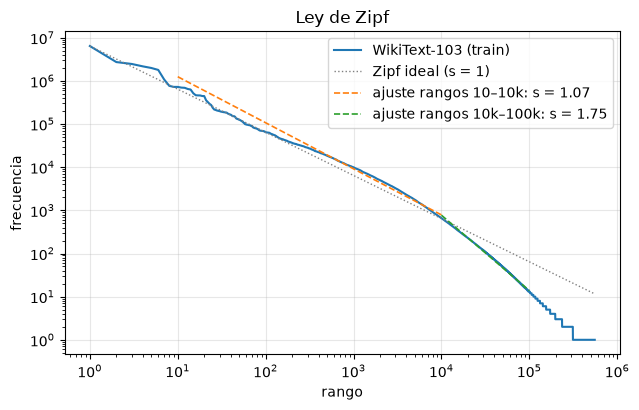

Top     10 palabras cubren  24.3 % de los tokens
Top  1,000 palabras cubren  64.6 % de los tokens
Top 30,000 palabras cubren  95.4 % de los tokens
10 más frecuentes: ['the', 'of', 'and', 'in', 'to', 'a', 'was', 'on', "'s", 'as']


In [10]:
frecs = np.array(sorted(conteo_total.values(), reverse=True), dtype=np.float64)
rangos = np.arange(1, len(frecs) + 1)

# Ajustes lineales en log-log para estimar el exponente s de Zipf, f(r) ∝ r^(-s), en dos tramos:
# cuerpo (rangos 10..10k) y cola (rangos 10k..100k).
def ajuste(r0, r1):
    sel = (rangos >= r0) & (rangos <= r1)
    m, b = np.polyfit(np.log10(rangos[sel]), np.log10(frecs[sel]), 1)
    return -m, b
s_cuerpo, b_cuerpo = ajuste(10, 10_000)
s_cola, b_cola = ajuste(10_000, 100_000)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.loglog(rangos, frecs, lw=1.5, label='WikiText-103 (train)')
ax.loglog(rangos, frecs[0] / rangos, ':', lw=1, color='gray', label='Zipf ideal (s = 1)')
r = np.array([10, 10_000]); ax.loglog(r, 10**b_cuerpo * r**(-s_cuerpo), '--', lw=1.2, label=f'ajuste rangos 10–10k: s = {s_cuerpo:.2f}')
r = np.array([10_000, 100_000]); ax.loglog(r, 10**b_cola * r**(-s_cola), '--', lw=1.2, label=f'ajuste rangos 10k–100k: s = {s_cola:.2f}')
ax.set_xlabel('rango'); ax.set_ylabel('frecuencia'); ax.set_title('Ley de Zipf')
ax.legend(); ax.grid(True, which='major', alpha=0.3)
fig.tight_layout(); fig.savefig(os.path.join(REPORTS, 'zipf.png'), dpi=150); plt.show()

cobertura = {k: frecs[:k].sum() / N_TOTAL * 100 for k in (10, 1_000, 30_000)}
for k, v in cobertura.items():
    print(f'Top {k:>6,} palabras cubren {v:5.1f} % de los tokens')
print('10 más frecuentes:', [w for w, _ in conteo_total.most_common(10)])

**¿Se cumple Zipf?** Sí, en buena medida: hasta el rango ~10 k la curva es casi una recta con pendiente ≈ −1
(frecuencia ∝ 1/rango), justo lo que dice Zipf. En la cola (rangos > 10 k) la pendiente se vuelve más empinada (s ≈ 1.75:
las palabras raras son aún más raras de lo que predice Zipf) y aparecen escalones (miles de palabras con frecuencia 1–2).
Consecuencia práctica: **unas pocas palabras dominan el corpus** (las 10 primeras, casi todas *stopwords*, ya son ~¼ de los
tokens) y con 30 k palabras se cubre el 95 % del texto. Por eso tiene sentido (1) un umbral `min_count` y (2) el
submuestreo de palabras frecuentes.

### 2.5 Subconjunto de entrenamiento

Por cómputo se usa un **subconjunto de ~25 M tokens** (el mínimo pedido es 20 M). Se toman artículos completos en orden
aleatorio (semilla fija) hasta llegar a 25 M; así el subconjunto es representativo de todo Wikipedia y no solo de los
primeros artículos. Los subconjuntos del 25 % y 50 % (sección 4) son **prefijos** de este mismo orden, así que están
anidados. Ambos modelos entrenados (SGNS propio y gensim) usan exactamente estas oraciones.

In [11]:
OBJETIVO_TOKENS = 2_000_000 if QUICK else 25_000_000

orden = list(range(len(articulos)))
random.Random(SEED).shuffle(orden)
oraciones_train, n_acum = [], 0
for i in orden:
    for p in articulos[i]:
        oraciones_train.append(p); n_acum += len(p)
    if n_acum >= OBJETIVO_TOKENS:
        break
conteo = Counter(w for p in oraciones_train for w in p)
N_SUB = sum(conteo.values())
print(f'Subconjunto: {len(oraciones_train):,} párrafos, {N_SUB:,} tokens, {len(conteo):,} tipos')

# Validación de WikiText-103 (texto no visto) para medir tokens desconocidos.
tokens_val = [w for l in corpus['validation']['text'] if l.strip() and not RE_SECCION.match(l) for w in tokenizar(l)]
print(f'Validación WikiText: {len(tokens_val):,} tokens')

Subconjunto: 249,147 párrafos, 25,004,742 tokens, 281,029 tipos
Validación WikiText: 182,245 tokens


### 2.6 Vocabulario y `min_count`

El vocabulario contiene solo las palabras con frecuencia ≥ `min_count` en el subconjunto. Se mide el porcentaje de tokens
desconocidos (que caerían en `<unk>`) tanto en el propio subconjunto como en la validación de WikiText (texto nuevo).

In [12]:
filas = []
for mc in (1, 3, 5, 10, 50, 100):
    vocab_mc = {w for w, c in conteo.items() if c >= mc}
    unk_train = sum(c for w, c in conteo.items() if c < mc) / N_SUB * 100
    unk_val = sum(1 for w in tokens_val if w not in vocab_mc) / len(tokens_val) * 100
    filas.append({'min_count': mc, 'vocabulario': len(vocab_mc),
                  '% <unk> subconjunto': round(unk_train, 2), '% <unk> validación': round(unk_val, 2)})
df_vocab = pd.DataFrame(filas)
display(df_vocab)
df_vocab.to_csv(os.path.join(REPORTS, 'vocab_min_count.csv'), index=False)

,min_count,vocabulario,% <unk> subconjunto,% <unk> validación
0,1,281029,0.00,0.99
1,3,122565,0.79,1.59
2,5,90273,1.23,1.87
3,10,61343,1.98,2.48
4,50,24379,5.21,5.37
5,100,15747,7.63,7.63


**Lectura:** subir `min_count` reduce el vocabulario muchísimo (la mayoría de los tipos son palabras raras, cola de Zipf)
pero el porcentaje de `<unk>` sube muy poco. Con `min_count = 5` el vocabulario se reduce ~3× respecto a usar todo (281 k → 90 k) y
solo ~1–2 % de los tokens quedan fuera. Además, una palabra que aparece 1–4 veces no tiene suficientes contextos para
aprender un vector útil. Se elige **`min_count = 5`** (igual que el default de gensim).

In [13]:
MIN_COUNT = 5
# Vocabulario ordenado por frecuencia (desempate alfabético): el índice 0 es la palabra más frecuente.
itos = [w for w, c in sorted(conteo.items(), key=lambda x: (-x[1], x[0])) if c >= MIN_COUNT]
stoi = {w: i for i, w in enumerate(itos)}
V = len(itos)
frec_vocab = np.array([conteo[w] for w in itos], dtype=np.float64)

# Texto crudo -> tokens -> IDs (las palabras fuera del vocabulario se descartan, como en Word2Vec).
ids_lista, oid_lista = [], []
for k, p in enumerate(oraciones_train):
    x = [stoi[w] for w in p if w in stoi]
    ids_lista.extend(x); oid_lista.extend([k] * len(x))
IDS = np.array(ids_lista, dtype=np.int32)     # corpus como secuencia de IDs
OID = np.array(oid_lista, dtype=np.int32)     # a qué párrafo pertenece cada token (las ventanas no cruzan párrafos)
del ids_lista, oid_lista

print(f'Vocabulario: {V:,} palabras | tokens en el vocabulario: {len(IDS):,} ({len(IDS) / N_SUB * 100:.1f} %)')
ejemplo = "The king's army didn't reach Paris in 1066."
print('texto  :', ejemplo)
print('tokens :', tokenizar(ejemplo))
print('IDs    :', [stoi.get(w, '<unk>') for w in tokenizar(ejemplo)])

# Cobertura en GloVe: qué tan compatible es nuestra normalización con su vocabulario.
en_glove = sum(conteo[w] for w in itos if w in glove.key_to_index) / frec_vocab.sum() * 100
print(f'{sum(w in glove.key_to_index for w in itos):,} de {V:,} palabras del vocabulario existen en GloVe '
      f'({en_glove:.1f} % de los tokens)')

Vocabulario: 90,273 palabras | tokens en el vocabulario: 24,698,313 (98.8 %)
texto  : The king's army didn't reach Paris in 1066.
tokens : ['the', 'king', "'s", 'army', 'did', "n't", 'reach', 'paris', 'in', '1066']
IDs    : [0, 207, 8, 222, 115, 254, 1122, 1518, 3, 18745]
83,928 de 90,273 palabras del vocabulario existen en GloVe (99.7 % de los tokens)


### 2.7 Submuestreo (*subsampling*) de palabras frecuentes

Word2Vec descarta aleatoriamente apariciones de palabras muy frecuentes. Con $f(w)$ = frecuencia relativa y umbral $t$,
la probabilidad de **conservar** una aparición (fórmula del código C de Word2Vec, la misma que usa gensim) es:

$$P_{keep}(w) = \min\left(1,\ \left(\sqrt{\tfrac{f(w)}{t}} + 1\right)\tfrac{t}{f(w)}\right)$$

(El paper original usa $P_{descartar} = 1 - \sqrt{t/f(w)}$; es casi la misma curva.) Se recalcula en **cada epoch**, así
que cada epoch ve una muestra distinta.

In [14]:
f_rel = frec_vocab / frec_vocab.sum()

def prob_conservar(t):
    return np.minimum(1.0, (np.sqrt(f_rel / t) + 1) * t / f_rel)

filas = []
for t in (1e-3, 1e-4, 1e-5):
    pk = prob_conservar(t)
    fila = {'t': t}
    for w in ('the', 'of', 'and'):
        fila[f'% descartado "{w}"'] = round((1 - pk[stoi[w]]) * 100, 1)
    fila['% tokens conservados (total)'] = round((pk * frec_vocab).sum() / frec_vocab.sum() * 100, 1)
    filas.append(fila)
df_sub = pd.DataFrame(filas)
display(df_sub)
df_sub.to_csv(os.path.join(REPORTS, 'subsampling.csv'), index=False)

,t,"% descartado ""the""","% descartado ""of""","% descartado ""and""",% tokens conservados (total)
0,0.00100,87.2,79.2,78.0,77.8
1,0.00010,96.2,94.1,93.8,60.1
2,0.00001,98.8,98.2,98.1,35.2


**¿Por qué ayuda?**

1. **Menos información redundante:** ver `the` junto a `france` no enseña nada sobre `france`; ver `paris` sí. Las
   stopwords aparecen en casi todas las ventanas y dominarían la pérdida.
2. **Velocidad:** con $t=10^{-4}$ se elimina ~40 % de los tokens (y ~94–96 % de `the`, `of`, `and`).
3. **Ventanas efectivamente más amplias:** al quitar stopwords, las palabras de contenido quedan más cerca entre sí,
   así que la misma ventana captura más contexto útil.
4. Mejora la calidad de los vectores de palabras raras (Mikolov et al., 2013).

Se usará **$t = 10^{-4}$** como valor principal (se explora en la sección 4).

### 2.8 Pares (palabra central, contexto) para skip-gram

Para cada palabra central $w_t$ se generan pares $(w_t, w_{t+j})$ con $-W \le j \le W,\ j \ne 0$, sin cruzar párrafos.
Word2Vec usa una **ventana dinámica**: para cada palabra central muestrea $b \sim U\{1..W\}$ y usa solo $|j| \le b$
(así los vecinos cercanos pesan más). Esta función, totalmente vectorizada con NumPy, es la que usará el entrenamiento.

In [15]:
def generar_pares(ids, oid, W, rng=None):
    """Devuelve arreglos (centro, contexto) de todos los pares skip-gram.
    ids: IDs del corpus; oid: párrafo de cada token; W: ventana máxima.
    Si rng no es None se usa ventana dinámica (b ~ U{1..W} por palabra central)."""
    M = len(ids)
    b = rng.integers(1, W + 1, M) if rng is not None else np.full(M, W)
    C, O = [], []
    for d in range(1, W + 1):
        i = np.arange(M - d)
        mismo = oid[i] == oid[i + d]                  # no cruzar párrafos
        m = mismo & (b[i] >= d)                      # i es el centro, i+d el contexto
        C.append(ids[i[m]]); O.append(ids[i[m] + d])
        m = mismo & (b[i + d] >= d)                  # i+d es el centro, i el contexto
        C.append(ids[i[m] + d]); O.append(ids[i[m]])
    return np.concatenate(C), np.concatenate(O)

# Ejemplo pequeño con un párrafo.
p_ej = tokenizar("The quick brown fox jumps over the lazy dog")
ids_ej = np.array([stoi[w] for w in p_ej], dtype=np.int32)
c_ej, o_ej = generar_pares(ids_ej, np.zeros(len(ids_ej), dtype=np.int32), W=2)
print('pares con W=2 para "fox":', [(itos[c], itos[o]) for c, o in zip(c_ej, o_ej) if itos[c] == 'fox'])

pares con W=2 para "fox": [('fox', 'jumps'), ('fox', 'brown'), ('fox', 'over'), ('fox', 'quick')]


In [16]:
W_PARES = 5
rng = np.random.default_rng(SEED)
filas = []
for nombre, ids_, oid_ in [('sin submuestreo', IDS, OID)] + [
        (f'con submuestreo t={t:g}', IDS[m], OID[m])
        for t in (1e-3, 1e-4, 1e-5)
        for m in [rng.random(len(IDS)) < prob_conservar(t)[IDS]]]:
    c_fijo, _ = generar_pares(ids_, oid_, W_PARES)                  # ventana fija W
    c_din, _ = generar_pares(ids_, oid_, W_PARES, rng)              # ventana dinámica (Word2Vec)
    filas.append({'corpus': nombre, 'tokens': len(ids_),
                  f'pares ventana fija W={W_PARES}': len(c_fijo),
                  'pares ventana dinámica': len(c_din)})
df_pares = pd.DataFrame(filas)
display(df_pares)
df_pares.to_csv(os.path.join(REPORTS, 'pares_skipgram.csv'), index=False)
del c_fijo, c_din

,corpus,tokens,pares ventana fija W=5,pares ventana dinámica
0,sin submuestreo,24698313,239625260,144762556
1,con submuestreo t=0.001,19218822,184841242,111884233
2,con submuestreo t=0.0001,14836903,141045800,85573573
3,con submuestreo t=1e-05,8704065,79868218,48870961


**Lectura:** con ventana fija cada token genera ~$2W = 10$ pares; con ventana dinámica el promedio es $W + 1 = 6$
(porque $E[b] = 3$ a cada lado). El submuestreo con $t=10^{-4}$ reduce los pares por epoch ~40 %: es la
principal razón por la que el entrenamiento se acelera, y lo que se elimina son sobre todo pares con stopwords.